## Workspace setup

In [3]:
from datetime import datetime 
import uproot
import awkward as ak
import tensorflow as tf
import numpy as np
import importlib
from functools import partial

from tensorflow.data import Dataset, TFRecordDataset
from tensorflow.data.experimental import TFRecordWriter
from tensorflow.train import BytesList, FloatList, Int64List
from tensorflow.train import Example, Features, Feature
import tensorflow_datasets as tfds

# Notebooks run from VSCode use home directory as a base path
# while notebooks run from JupyterLab use the current directory as a base path
import sys
sys.path.append("/home/akalinow/scratch/ELITPC/TPCReco/PythonAnalysis/python/")

# Change directory to the working directory
import os
os.chdir('/home/marcel/Desktop/work/work_dir/') # my working directory

import io_functions as io

### Load and convert SimEvent data

In [4]:
%%time
importlib.reload(io)

dataPath = '/home/akalinow/scratch/ELITPC/TPCReco/build/resources/'
rootfiles = [dataPath+'SimEvent_Track3D_TwoProng_gun_MC.root:TPCData']
outputDir = 'SimEvent_Track3D_TwoProng_gun_MC'

# Convert ROOT files to TF format and save to output directory
io.convertROOT(rootfiles, outputDir, fields= io.simEventFields)

# Load the dataset and benchmark it
batchSize = 32
simDataset = tf.data.Dataset.load(outputDir, compression="GZIP")
simDataset = simDataset.batch(batchSize).cache()

tfds.benchmark(simDataset, batch_size=batchSize)

# Second pass profiting from the cache
tfds.benchmark(simDataset, batch_size=batchSize)

Instructions for updating:
Use output_signature instead


2025-07-22 21:00:11.417797: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:282] failed call to cuInit: CUDA_ERROR_COMPAT_NOT_SUPPORTED_ON_DEVICE: forward compatibility was attempted on non supported HW
2025-07-22 21:00:11.417873: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:134] retrieving CUDA diagnostic information for host: Marcel-PC-U
2025-07-22 21:00:11.417879: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:141] hostname: Marcel-PC-U
2025-07-22 21:00:11.417954: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:165] libcuda reported version is: INVALID_ARGUMENT: expected %d.%d, %d.%d.%d, or %d.%d.%d.%d form for driver version; got "1"
2025-07-22 21:00:11.417978: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:169] kernel reported version is: 550.144.3
2025-07-22 21:00:15.753840: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 295698432 exceeds 10% of free system memory


************ Summary ************



  0%|          | 0/20 [00:00<?, ?it/s]

2025-07-22 21:00:22.999943: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 50331648 exceeds 10% of free system memory.


...

2025-07-22 21:00:25.558767: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  0%|          | 0/20 [00:00<?, ?it/s]

Examples/sec (First included) 95730.12 ex/sec (total: 672 ex, 0.01 sec)
Examples/sec (First only) 6796.66 ex/sec (total: 32 ex, 0.00 sec)
Examples/sec (First excluded) 276871.94 ex/sec (total: 640 ex, 0.00 sec)
CPU times: user 12.1 s, sys: 6.72 s, total: 18.8 s
Wall time: 14.2 s


2025-07-22 21:00:25.570248: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


,duration,num_examples,avg
first+lasts,0.007020,672,95730.123107
first,0.004708,32,6796.658423
lasts,0.002312,640,276871.935482


### Load and convert RecoEvent data

In [5]:
%%time
importlib.reload(io)

dataPath = '/home/akalinow/scratch/ELITPC/TPCReco/build/resources/'
# uproot always takes the first branch with given name, unless 
# explicit branch is givent as input path. Filtering by branches in
# iterate does not work. 
rootfiles = [dataPath+'SimEvent_Track3D_TwoProng_gun_MC.root:TPCData/RecoEvent']
outputDir = 'RecoEvent_Track3D_TwoProng_gun_MC'

# Convert ROOT files to TF format and save to output directory
io.convertROOT(rootfiles, outputDir, fields=io.recoEventFields)

# Load the dataset and benchmark it
batchSize = 32
recoDataset = tf.data.Dataset.load(outputDir, compression="GZIP")
recoDataset = recoDataset.batch(batchSize).cache()

tfds.benchmark(recoDataset, batch_size=batchSize)

# Second pass profiting from the cache
tfds.benchmark(recoDataset, batch_size=batchSize)


************ Summary ************



  0%|          | 0/20 [00:00<?, ?it/s]

Examples/sec (First included) 30414.88 ex/sec (total: 672 ex, 0.02 sec)
Examples/sec (First only) 2111.95 ex/sec (total: 32 ex, 0.02 sec)
Examples/sec (First excluded) 92184.83 ex/sec (total: 640 ex, 0.01 sec)

************ Summary ************



2025-07-22 21:00:25.847542: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  0%|          | 0/20 [00:00<?, ?it/s]

Examples/sec (First included) 79376.24 ex/sec (total: 672 ex, 0.01 sec)
Examples/sec (First only) 5049.80 ex/sec (total: 32 ex, 0.01 sec)
Examples/sec (First excluded) 300592.68 ex/sec (total: 640 ex, 0.00 sec)
CPU times: user 241 ms, sys: 22.8 ms, total: 264 ms
Wall time: 249 ms


2025-07-22 21:00:25.857717: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


,duration,num_examples,avg
first+lasts,0.008466,672,79376.244462
first,0.006337,32,5049.802095
lasts,0.002129,640,300592.684232


### Merge SimEvent and RecoEvent data


In [6]:
# merge SimEvent and RecoEvent data
simDataset = tf.data.Dataset.load('SimEvent_Track3D_TwoProng_gun_MC', compression="GZIP")
recoDataset = tf.data.Dataset.load('RecoEvent_Track3D_TwoProng_gun_MC', compression="GZIP")

mergedDataset = tf.data.Dataset.zip((simDataset, recoDataset))
mergedDataset = mergedDataset.map(
    lambda sim, reco: {
        'sim': sim,
        'reco': reco
    }
)

# filter merged dataset
# salculate sim alpha length and select events with legth > 20 mm
minAlphaLength = 20.0
mergedDataset = mergedDataset.filter(
    lambda x: tf.reduce_all(
        tf.greater(
            tf.sqrt(
                tf.math.reduce_sum(tf.square(x['sim'][1][:,0] - x['sim'][1][:,1]), axis=-1)
            ), minAlphaLength
        )
    )
)

# save merged dataset
outputDir = 'MergedEvent_Track3D_TwoProng_gun_MC'
mergedDataset.save(outputDir, compression="GZIP")

### Plot a test event

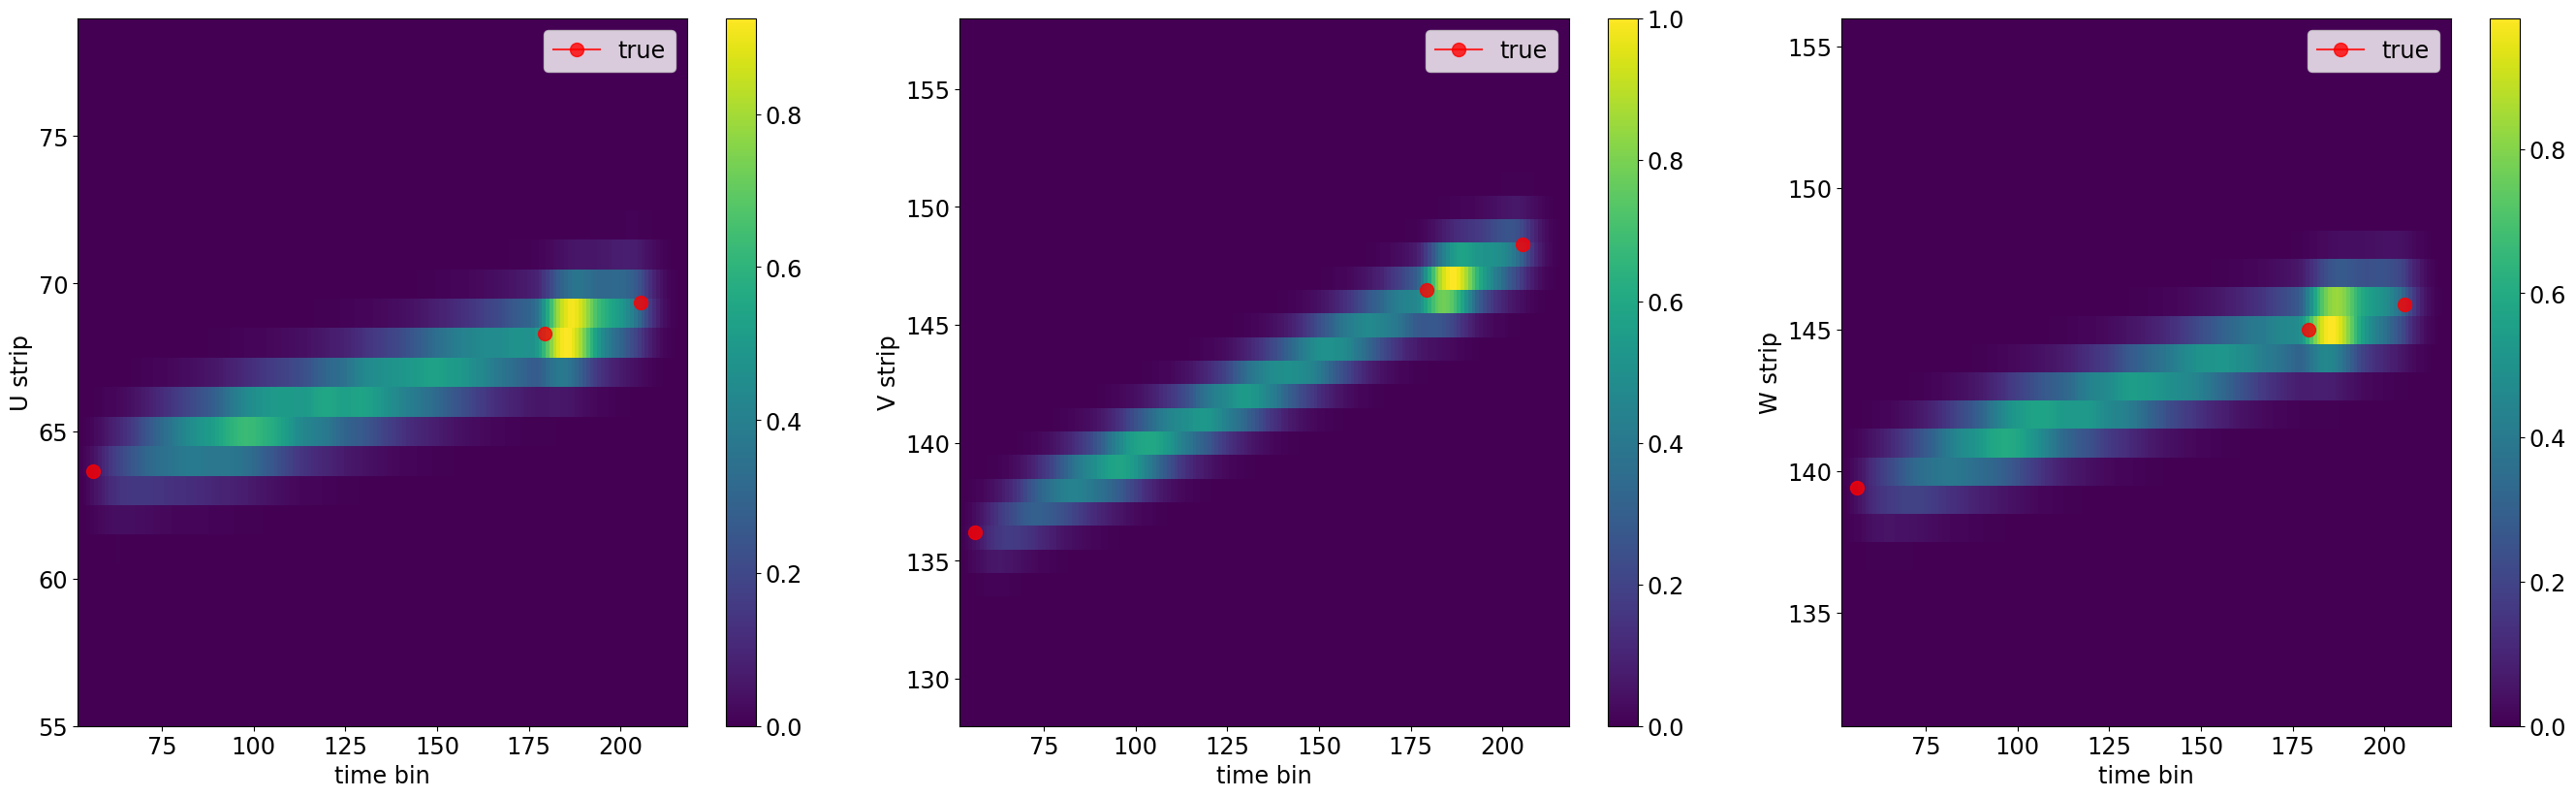

In [7]:
simDataset = tf.data.Dataset.load('SimEvent_Track3D_TwoProng_gun_MC', compression="GZIP")

import plotting_functions as plf
importlib.reload(plf)

item = next(iter(simDataset.batch(1)))
plf.plotEvent(item, model=None)